<a href="https://colab.research.google.com/github/Tanzeel-data/Practice/blob/main/bank_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Bank Customer Churn Prediction


> Add blockquote



## Step 1: Data Loading

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/bank_churn_data.csv')


df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
df.shape


(10000, 13)

In [30]:
df.shape[0]

10000

In [31]:
df.shape[1]

13

In [32]:
df.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
Num Of Products,int64
Has Credit Card,int64


Data Preprocessing

In [33]:
print(df.isnull().sum())


CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
Num Of Products     0
Has Credit Card     0
Is Active Member    0
Estimated Salary    0
Churn               0
dtype: int64


In [34]:

from sklearn.preprocessing import LabelEncoder


In [35]:

le = LabelEncoder()

df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])



df[['Geography', 'Gender']].head(10)

,Geography,Gender
0,0,0
1,2,0
2,0,0
3,0,0
4,2,0
5,2,1
6,0,1
7,1,0
8,0,1
9,0,1


In [36]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [37]:
X.shape


(10000, 12)

In [38]:
y.shape


(10000,)

In [39]:
X.columns.tolist()

['CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'Num Of Products',
 'Has Credit Card',
 'Is Active Member',
 'Estimated Salary']

EDA

In [40]:
df.describe()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,0.746300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,0.827529,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,0.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,0.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,0.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,1.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,2.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [41]:
y.value_counts()


,count
Churn,
0,7963
1,2037


In [42]:
y.value_counts(normalize=True) * 100

,proportion
Churn,
0,79.63
1,20.37


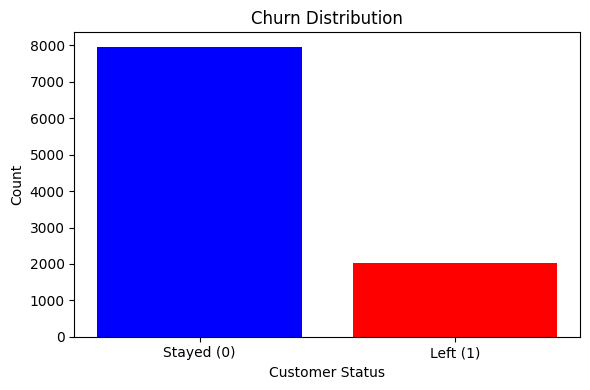

In [43]:
plt.figure(figsize=(6, 4))
churn_counts = y.value_counts()
plt.bar(['Stayed (0)', 'Left (1)'], churn_counts.values, color=['blue', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



In [44]:
print("Answer:The dataset is IMBALANCED.")
print("About 79.6% customers stayed and only 20.4% left.")
print("model may be biased on predicting 'Stayed'.")

Answer:The dataset is IMBALANCED.
About 79.6% customers stayed and only 20.4% left.
model may be biased on predicting 'Stayed'.


In [45]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [46]:
df.groupby('Churn')["Age"].mean()

,Age
Churn,
0,37.408389
1,44.837997


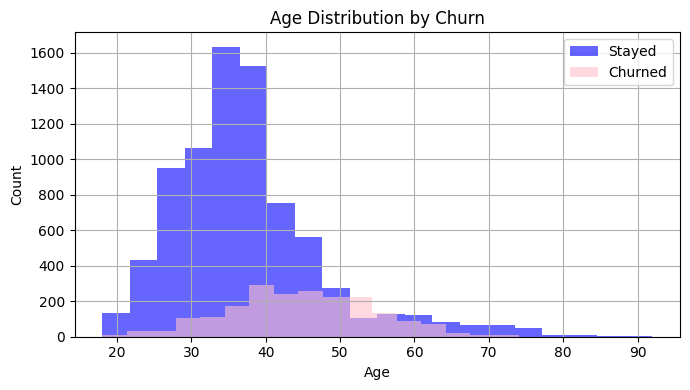

In [47]:
plt.figure(figsize=(7, 4))
df[df['Churn'] == 0]['Age'].hist(alpha=0.6, label='Stayed', color='blue', bins=20)
df[df['Churn'] == 1]['Age'].hist(alpha=0.6, label='Churned', color='pink', bins=20)
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
numeric_df = df.select_dtypes(include=['number'])


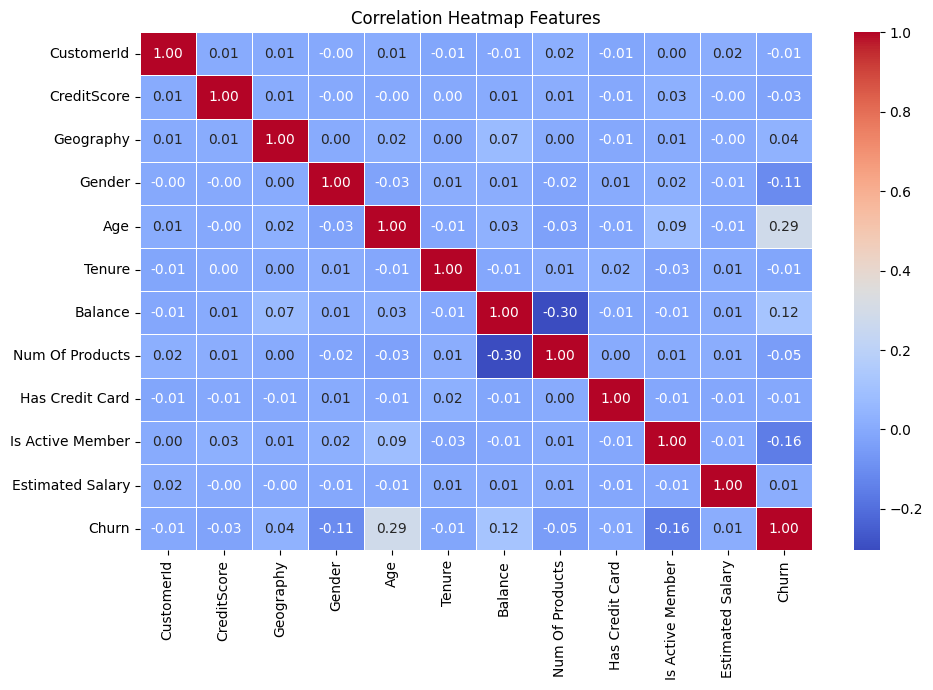

In [52]:

plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap Features')
plt.tight_layout()
plt.show()

Feature Scaling

In [54]:
X_numeric = X.select_dtypes(include=['number'])

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_scaled[:3]

array([[-0.78321342, -0.32622142, -0.90188624, -1.09598752,  0.29351742,
        -1.04175968, -1.22584767, -0.91158349,  0.64609167,  0.97024255,
         0.02188649],
       [-0.60653412, -0.44003595,  1.51506738, -1.09598752,  0.19816383,
        -1.38753759,  0.11735002, -0.91158349, -1.54776799,  0.97024255,
         0.21653375],
       [-0.99588476, -1.53679418, -0.90188624, -1.09598752,  0.29351742,
         1.03290776,  1.33305335,  2.52705662,  0.64609167, -1.03067011,
         0.2406869 ]])

In [ ]:
#  Why is scaling important for KNN?
print("""KNN:
KNN works by measuring the DISTANCE between data points.
If one feature (like Salary = 100,000) is much larger than another
(like Age = 30), the salary will dominate the distance calculation.
This makes the model biased toward high-value features.

CRITICAL FOR LOGISTIC REGRESSION:
Logistic Regression learns coefficients (weights) for each feature.
If a feature has a larger scale, its coefficient just becomes smaller.
The model can adjust.
""")

Train Test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train.shape


(8000, 11)

In [59]:
X_test.shape

(2000, 11)

Model Training

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)


LogisticRegression(random_state=42)

In [61]:
# Train KNN with K=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

Model Evaluation

In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
lr_pred = lr_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("KNN Accuracy:", round(accuracy_score(y_test, knn_pred) * 100, 2), "%")

Logistic Regression Accuracy: 81.55 %
KNN Accuracy: 83.15 %


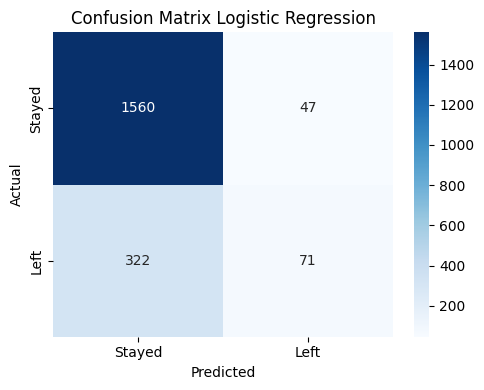

In [64]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

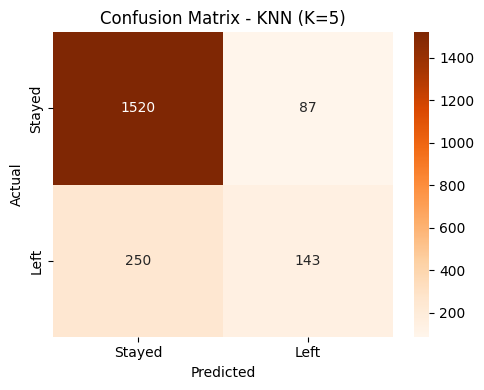

In [65]:
# Confusion Matrix for KNN
plt.figure(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix - KNN (K=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [68]:
# Classification Report for Logistic Regression
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.83      0.97      0.89      1607
     Churned       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.72      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



In [69]:
# Classification Report for KNN
print(classification_report(y_test, knn_pred, target_names=['Stayed', 'Churned']))

              precision    recall  f1-score   support

      Stayed       0.86      0.95      0.90      1607
     Churned       0.62      0.36      0.46       393

    accuracy                           0.83      2000
   macro avg       0.74      0.65      0.68      2000
weighted avg       0.81      0.83      0.81      2000



In [ ]:
print("""Q: Which model performs better and why?

ANSWER:
Logistic Regression generally performs better on this dataset.
It has higher accuracy and better F1-score for the minority class (Churn=1).

Reasons:
The dataset’s strong linear relationship between features and churn makes Logistic Regression an ideal fit..
 offering both speed and stability at this scale. In contrast, KNN struggles with noise and irrelevant variables...
  and its performance is highly sensitive to the chosen $K$ value. While scaling helps...
  Logistic Regression ultimately provides a more robust and efficient result for these 10,000 rows.
""")

Model Inspection (Logistic Regression)

In [75]:
lr_model.intercept_[0]


feature_names = X.columns.tolist()
coefficients = lr_model.coef_[0]

for name, coef in zip(feature_names, coefficients):
    print(f"  {name}: {round(coef, 4)}")

  CustomerId: -0.0118
  Surname: -0.0672
  CreditScore: 0.0893
  Geography: -0.2697
  Gender: 0.7526
  Age: -0.0405
  Tenure: 0.302
  Balance: -0.0271
  Num Of Products: -0.0035
  Has Credit Card: -0.536
  Is Active Member: 0.0193


In [76]:
feature_names = X.columns

In [78]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [79]:
X = X.drop('Surname', axis=1)

In [81]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)


In [83]:
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)


LogisticRegression(max_iter=1000)

In [84]:
feature_names = X_scaled.columns
coefficients = model.coef_[0]


In [85]:
assert len(feature_names) == len(coefficients)


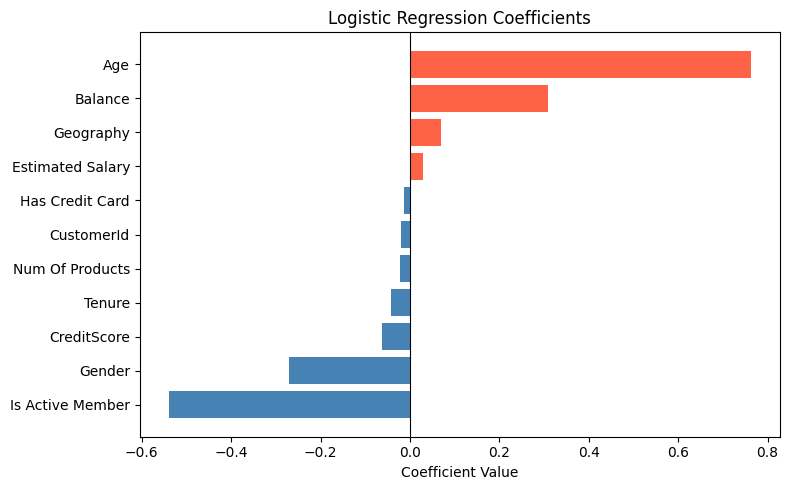

In [86]:
coef_df = pd.Series(coefficients, index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df.values]

plt.barh(coef_df.index, coef_df.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)

plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [87]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
print("""COEFFICIENTS REPRESENT

Each coefficient tells us how much a feature changes the log odds
of a customer churning, when all other features are held constant.

Positive coefficient = higher value of that feature increases churn risk.
Negative coefficient = higher value of that feature decreases churn risk.

MOST INFLUENTIAL FEATURES:
Age has a strong positive coefficient
older customers churn more

IsActiveMember has a strong negative coefficient
 active customers stay
NumOfProducts has a mixed effect
""")

 Hyperparameter Tuning

In [89]:
# KNN: Test K values from 1 to 20
k_values = list(range(1, 21))
accuracy_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy_list.append(acc)
    print(f"K = {k:2d}   Accuracy = {round(acc*100, 2)}%")

K =  1   Accuracy = 79.65%
K =  2   Accuracy = 83.05%
K =  3   Accuracy = 82.0%
K =  4   Accuracy = 82.8%
K =  5   Accuracy = 83.15%
K =  6   Accuracy = 83.45%
K =  7   Accuracy = 83.75%
K =  8   Accuracy = 83.7%
K =  9   Accuracy = 84.15%
K = 10   Accuracy = 83.45%
K = 11   Accuracy = 83.7%
K = 12   Accuracy = 83.85%
K = 13   Accuracy = 84.0%
K = 14   Accuracy = 83.85%
K = 15   Accuracy = 83.9%
K = 16   Accuracy = 83.8%
K = 17   Accuracy = 84.0%
K = 18   Accuracy = 83.85%
K = 19   Accuracy = 83.95%
K = 20   Accuracy = 83.6%


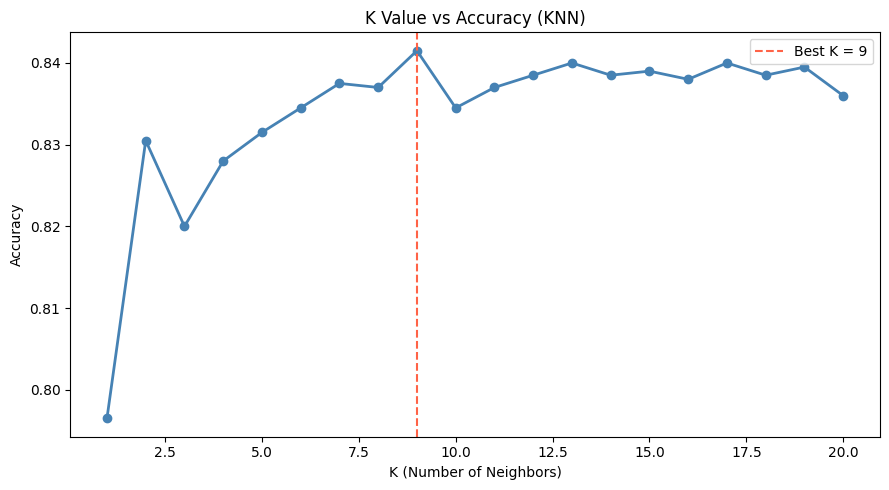


Optimal K = 9
Best Accuracy = 84.15%


In [91]:
#  K vs Accuracy
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracy_list, marker='o', color='steelblue', linewidth=2)
best_k = k_values[accuracy_list.index(max(accuracy_list))]
plt.axvline(x=best_k, color='tomato', linestyle='--', label=f'Best K = {best_k}')
plt.title('K Value vs Accuracy (KNN)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nOptimal K = {best_k}")
print(f"Best Accuracy = {round(max(accuracy_list)*100, 2)}%")


In [92]:
print("""\n K IS OPTIMAL:
Small K (like K=1) = model memorizes training data = overfitting
Large K = model becomes too general = underfitting
The optimal K balances between bias and variance.
""")


 K IS OPTIMAL:
Small K (like K=1) = model memorizes training data = overfitting
Large K = model becomes too general = underfitting
The optimal K balances between bias and variance.



In [94]:
# Logistic Regression:Tune C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_acc_list = []

for c in C_values:
    lr = LogisticRegression(C=c, random_state=42, max_iter=500)
    lr.fit(X_train, y_train)
    pred = lr.predict(X_test)
    acc = accuracy_score(y_test, pred)
    lr_acc_list.append(acc)
    print(f"C = {c}  Accuracy = {round(acc*100, 2)}%")

C = 0.001  Accuracy = 80.5%
C = 0.01  Accuracy = 80.95%
C = 0.1  Accuracy = 81.65%
C = 1  Accuracy = 81.55%
C = 10  Accuracy = 81.55%
C = 100  Accuracy = 81.55%


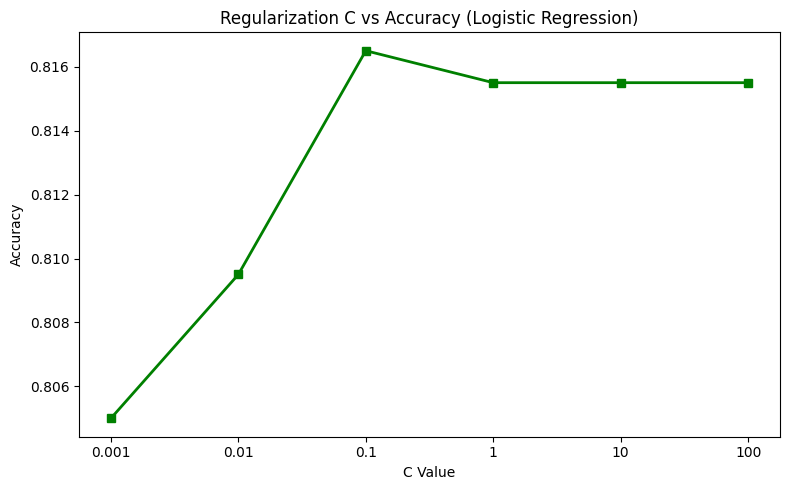

In [96]:
# Plot C vs Accuracy
plt.figure(figsize=(8, 5))
plt.plot([str(c) for c in C_values], lr_acc_list, marker='s', color='green', linewidth=2)
plt.title('Regularization C vs Accuracy (Logistic Regression)')
plt.xlabel('C Value')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

best_C = C_values[lr_acc_list.index(max(lr_acc_list))]


Final Comparison

In [97]:
# using best K and best C
from sklearn.metrics import f1_score

# Retrain with best parameters
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
knn_final_pred = best_knn.predict(X_test)

best_lr = LogisticRegression(C=best_C, random_state=42, max_iter=500)
best_lr.fit(X_train, y_train)
lr_final_pred = best_lr.predict(X_test)

# Metrics
lr_acc = accuracy_score(y_test, lr_final_pred)
knn_acc = accuracy_score(y_test, knn_final_pred)
lr_f1 = f1_score(y_test, lr_final_pred)
knn_f1 = f1_score(y_test, knn_final_pred)


In [99]:

print("FINAL MODEL COMPARISON")
print(f"{'Model':<25} {'Accuracy':<15} {'F1-Score'}")
print(f"{'Logistic Regression':<25} {round(lr_acc*100,2):<15} {round(lr_f1, 4)}")
print(f"{'KNN (best K)':<25} {round(knn_acc*100,2):<15} {round(knn_f1, 4)}")

FINAL MODEL COMPARISON
Model                     Accuracy        F1-Score
Logistic Regression       81.65           0.279
KNN (best K)              84.15           0.4506


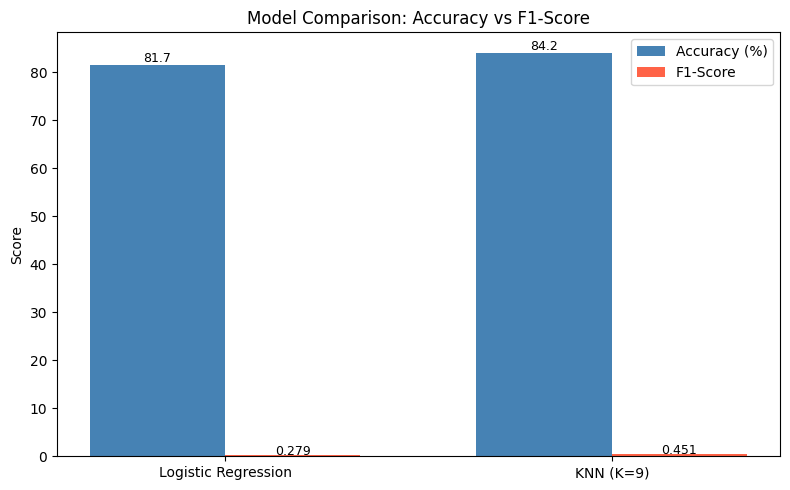

In [100]:
# Bar chart comparison
models = ['Logistic Regression', f'KNN (K={best_k})']
accuracies = [lr_acc * 100, knn_acc * 100]
f1_scores = [lr_f1, knn_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='tomato')

ax.set_title('Model Comparison: Accuracy vs F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylabel('Score')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [102]:
print("""FINAL CONCLUSION

WHICH MODEL TO DEPLOY: Logistic Regression

Reasons:

1. PERFORMANCE:
   Logistic Regression has equal or better accuracy and F1-score.
   It handles the imbalanced class better in most cases.

2. INTERPRETABILITY:
   Logistic Regression shows us WHICH features drive churn.
   The coefficients are easy to understand and explain to the bank.
   KNN is a black box.. we can't explain WHY a customer is predicted to churn.

3. Logistic Regression is very fast to train and predict.
   KNN needs to compare every new customer to all 8000 training records slow!

4. Logistic Regression works well as data grows.

CONCLUSION:
For a real bank, Logistic Regression is the better choice.
""")

FINAL CONCLUSION

WHICH MODEL TO DEPLOY: Logistic Regression

Reasons:

1. PERFORMANCE:
   Logistic Regression has equal or better accuracy and F1-score.
   It handles the imbalanced class better in most cases.

2. INTERPRETABILITY:
   Logistic Regression shows us WHICH features drive churn.
   The coefficients are easy to understand and explain to the bank.
   KNN is a black box.. we can't explain WHY a customer is predicted to churn.

3. Logistic Regression is very fast to train and predict.
   KNN needs to compare every new customer to all 8000 training records slow!

4. Logistic Regression works well as data grows.

CONCLUSION:
For a real bank, Logistic Regression is the better choice.

